# 11. Colon mct mc donor

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{mct_dir}entex_2_rna.h5ad'`  ·  _scRNA/expr_
- `f'{mct_dir}entex_2.mcds'`  ·  _mC matrix (mcds)_
- `f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz'`  ·  _joint summary obj_
- `f'{m3c_dir}*{tissue}*.mcds'`  ·  _mC matrix (mcds)_
- `f'{outdir}5kCG.h5ad'`  ·  _other_
- `f'{indir}clustering/tissue/L1/{tissue}/5kCG.h5ad'`  ·  _other_
- `f'{outdir}5kCG_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{outdir}{tissue}_mCT_m3C_{donor}_merged.h5ad'`  ·  _other_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize

from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.mcds import MCDS

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [2]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [3]:
indir = f'{ENTEX_ROOT}/'
mct_dir = f'{indir}mCT/'
m3c_dir = f'{indir}mcds/'
outdir = f'{indir}analysis/colon_mct/'
tissue = 'TrCo'

In [4]:
var_dim = 'chrom5k'
chrom_to_remove = ['chrX', 'chrY', 'chrM', 'chrL']
black_list_path = f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz'


In [7]:
meta = anndata.read_h5ad(f'{mct_dir}entex_2_rna.h5ad', 'r').obs
selc = meta.index[(meta['FinalDNAReads']>500000) & (meta['mCCCFrac']<0.1)]
print(len(selc))


5968


In [8]:
mcds = MCDS.open(f'{mct_dir}entex_2.mcds', use_obs=selc, var_dim=var_dim)
mcds = mcds.remove_chromosome(exclude_chromosome=chrom_to_remove, var_dim=var_dim)
mcds

42669 chrom5k features in ['chrX', 'chrY', 'chrM', 'chrL'] removed.


<xarray.MCDS> Size: 7GB
Dimensions:                    (cell: 5968, chrom5k: 575010)
Coordinates:
  * cell                       (cell) <U22 525kB 'pt4_TrCo_P16-2-C18-G4' ... ...
  * chrom5k                    (chrom5k) <U11 25MB 'chr1_0' ... 'chr9_27678'
    chrom5k_chrom              (chrom5k) <U5 12MB 'chr1' 'chr1' ... 'chr9'
    chrom5k_end                (chrom5k) int64 5MB ...
    chrom5k_start              (chrom5k) int64 5MB ...
Data variables:
    chrom5k_da_CGN-hypo-score  (cell, chrom5k) float16 7GB dask.array<chunksize=(7, 77210), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom5k

In [9]:
mcad = mcds.get_score_adata(mc_type='CGN', quant_type='hypo')
binarize_matrix(mcad, cutoff=0.95)
filter_regions(mcad, n_cell=5)
remove_black_list_region(mcad, black_list_path=black_list_path)
mcad.write_h5ad(f'{outdir}5kCG.h5ad')


Loading chunk 0-5968/5968


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


528745 regions remained.
18678 regions removed due to overlapping (bedtools intersect -f 0.2) with black list regions.


In [10]:
model = LSI(scale_factor=10000,
            n_components=50,
            algorithm='arpack',
            random_state=0)


In [11]:
raw_key = '5kCG_lsi'
obsm_key = 'X_lsi'
model.fit_transform(mcad, obsm_name='5kCG_lsi')
npc = significant_pc_test(mcad, p_cutoff=0.1, obsm=raw_key, update=False)


16 components passed P cutoff of 0.1.


In [14]:
mcad.obs['Donor'] = 'PT-1LVAN'

In [15]:
mcad.obsm[obsm_key] = normalize(mcad.obsm[raw_key][:, :npc], axis=1)
tsne(mcad, obsm=obsm_key, metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
mcad.obsm[f'5kCG_u{npc}_tsne'] = mcad.obsm['X_tsne'].copy()


In [16]:
sc.pp.neighbors(mcad, use_rep=obsm_key, n_neighbors=25)
sc.tl.leiden(mcad, resolution=1.0, key_added=f'5kCG_u{npc}_leiden')

/tmp/ipykernel_61374/3692068243.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(mcad, resolution=1.0, key_added=f'5kCG_u{npc}_leiden')


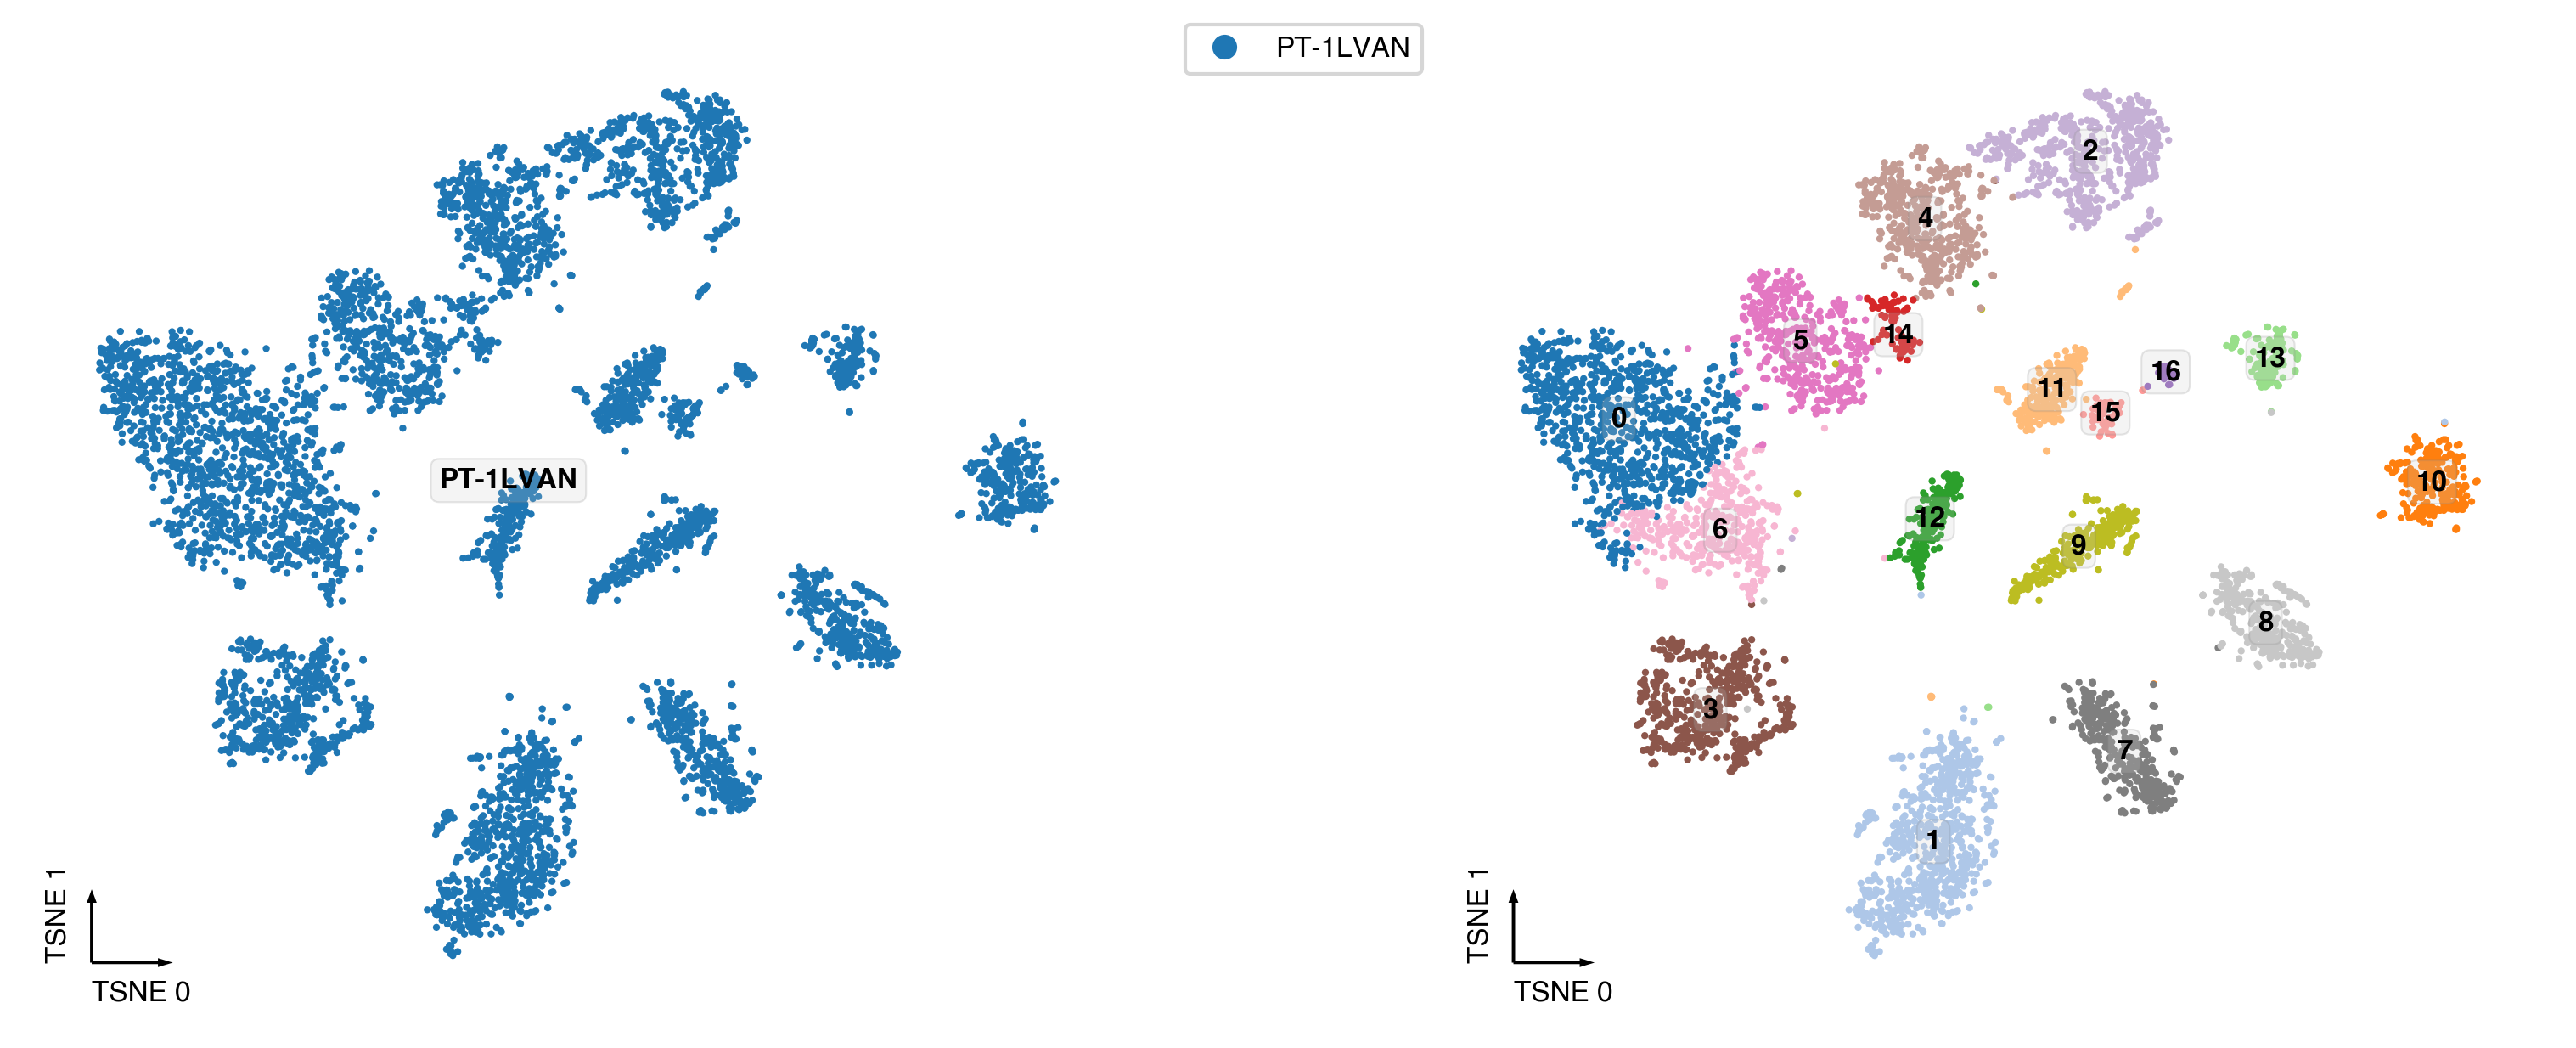

In [19]:
ds = 4
coord_base = 'tsne'

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300, constrained_layout=True)

mcad.obsm[f'X_{coord_base}'] = mcad.obsm[f'5kCG_u{npc}_tsne'].copy()
dump_embedding(mcad, coord_base)
tmp = mcad.obs.copy()
ax = axes[0]
_ = categorical_scatter(data=tmp,
                        ax=ax,
                        coord_base=coord_base,
                        hue='Donor',
                        text_anno='Donor',
                        labelsize=8,
                        s=ds,
                        palette='tab10',
                        scatter_kws={'rasterized':True},
                        # legend_kws={'ncol':1},
                        show_legend=True
                        )
ax = axes[1]
_ = categorical_scatter(data=tmp,
                        ax=ax,
                        coord_base=coord_base,
                        hue=f'5kCG_u{npc}_leiden',
                        text_anno=f'5kCG_u{npc}_leiden',
                        labelsize=8,
                        s=ds,
                        palette='tab20',
                        scatter_kws={'rasterized':True},
                        # legend_kws={'ncol':1},
                        # show_legend=True
                        )


In [20]:
mcad = anndata.AnnData(obs=mcad.obs, obsm=mcad.obsm, obsp=mcad.obsp)
mcad.write_h5ad(f'{outdir}5kCG_embed.h5ad')


In [21]:
meta = pd.read_csv(f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz', header=0, index_col=0)
meta[['Donor', 'Tissue', 'cluster', 'subtype', 'majortype']] = meta[['Donor', 'Tissue', 'cluster', 'subtype', 'majortype']].astype(str)
meta = meta.loc[meta['Tissue']==tissue]
meta

,cluster,subtype,majortype,FinalmCReads,mCHFrac,mCGFrac,CisLongContact,Cis/Trans,Short/Long,Donor,...,L2_5kCG_tsne_0,L2_5kCG_tsne_1,L2_100k3C_tsne_0,L2_100k3C_tsne_1,Tissue_joint_tsne_0,Tissue_joint_tsne_1,Tissue_5kCG_tsne_0,Tissue_5kCG_tsne_1,Tissue_100k3C_tsne_0,Tissue_100k3C_tsne_1
cell,,,,,,,,,,,,,,,,,,,,,
TrCo_A9HOW_Plate1-6-G12-A24,c21-c1,c21-b0,c21,2659544,0.010988,0.774266,254759,1.139963,-0.351935,PT-1LGRB,...,25.624958,3.941422,-2.742399,9.719993,27.421096,28.685944,45.425038,2.278493,2.168321,30.184624
TrCo_A9HOW_Plate2-5-N22-I10,c21-c1,c21-b0,c21,1226764,0.011274,0.737958,117485,1.292749,-0.289111,PT-1LGRB,...,25.788890,-0.706697,-0.938969,19.760522,27.516706,29.040235,45.967408,2.401296,2.606676,30.427102
TrCo_A9HOW_Plate4-1-C18-E1,c21-c1,c21-b0,c21,2102640,0.009389,0.752453,206938,1.275513,-0.020122,PT-1LGRB,...,25.363439,3.111327,1.643228,6.603093,27.230831,28.491698,45.394065,2.344305,1.035777,29.981787
TrCo_A9HOW_Plate4-5-A11-O10,c21-c1,c21-b0,c21,1638393,0.011846,0.762101,136359,1.099536,-0.149476,PT-1LGRB,...,27.582609,-11.841487,-2.136189,18.331474,27.458227,28.873199,45.801312,2.615741,1.914748,30.483753
TrCo_A9HOW_Plate5-1-E6-C2,c21-c1,c21-b0,c21,1673394,0.009544,0.734140,160699,1.222445,0.060156,PT-1LGRB,...,23.482146,1.865734,0.113866,5.951356,27.236113,28.304750,45.634441,2.370927,0.538565,29.808609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TrCo_A9VP4_Plate4-2-B4-G4,c28-c6,c28-b0,c28,2120838,0.008646,0.666970,209244,0.797941,-0.740200,PT-1LVAN,...,17.555380,-0.433491,-19.254808,4.320374,7.662408,47.254423,33.868149,-22.436025,-5.451874,31.985306
TrCo_A9VP4_Plate4-6-C19-A24,c28-c6,c28-b0,c28,3299271,0.009060,0.699752,332199,1.120303,-0.553636,PT-1LVAN,...,16.861077,-1.124382,-12.387314,6.830737,7.189614,47.116155,33.085391,-23.200122,-4.226496,31.835236
TrCo_A9VP4_Plate5-3-E10-D18,c28-c6,c28-b0,c28,1997761,0.010990,0.730792,221836,1.097058,-0.366444,PT-1LVAN,...,0.960841,-20.549915,-21.548914,3.294188,8.257962,47.708467,34.733543,-22.863765,-4.248699,30.505151


In [22]:
mcds = MCDS.open(f'{m3c_dir}*{tissue}*.mcds', use_obs=meta.index, var_dim=var_dim)
mcds = mcds.remove_chromosome(exclude_chromosome=chrom_to_remove, var_dim=var_dim)
mcds

42659 chrom5k features in ['chrX', 'chrY', 'chrM', 'chrL'] removed.


<xarray.MCDS> Size: 7GB
Dimensions:                    (cell: 5836, chrom5k: 575010)
Coordinates:
  * cell                       (cell) <U27 630kB 'TrCo_A9HOW_Plate1-1-H22-A1'...
  * chrom5k                    (chrom5k) <U11 25MB 'chr1_0' ... 'chr9_27678'
    chrom5k_chrom              (chrom5k) <U5 12MB 'chr1' 'chr1' ... 'chr9'
    chrom5k_end                (chrom5k) int64 5MB ...
    chrom5k_start              (chrom5k) int64 5MB ...
Data variables:
    chrom5k_da_CGN-hypo-score  (cell, chrom5k) float16 7GB dask.array<chunksize=(7, 77209), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom5k

In [23]:
mcad = mcds.get_score_adata(mc_type='CGN', quant_type='hypo')
binarize_matrix(mcad, cutoff=0.95)
filter_regions(mcad, n_cell=5)
remove_black_list_region(mcad, black_list_path=black_list_path)
mcad.write_h5ad(f'{indir}clustering/tissue/L1/{tissue}/5kCG.h5ad')


Loading chunk 0-5836/5836


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


517638 regions remained.
11555 regions removed due to overlapping (bedtools intersect -f 0.2) with black list regions.


In [24]:
adata1 = anndata.read_h5ad(f'{outdir}5kCG.h5ad')
adata2 = anndata.read_h5ad(f'{indir}clustering/tissue/L1/{tissue}/5kCG.h5ad')
print(adata1.shape, adata2.shape)


(5968, 510067) (5836, 506083)


In [25]:
meta = anndata.read_h5ad(f'{outdir}5kCG_embed.h5ad').obs
adata1.obs = meta.loc[adata1.obs.index].copy()
# adata1.obs['Donor'] = adata1.obs['Donor'].replace({'JFINP': 'PT-1LVAN', 'IOBHV': 'PT-1LGRB'})
adata1.obs['Donor'].value_counts()

/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Donor
PT-1LVAN    5968
Name: count, dtype: int64

In [26]:
meta = pd.read_csv(f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz', header=0, index_col=0)
meta[['Donor', 'Tissue', 'cluster', 'subtype', 'majortype']] = meta[['Donor', 'Tissue', 'cluster', 'subtype', 'majortype']].astype(str)
meta = meta.loc[meta['Tissue']==tissue]
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_color = L1_meta['color'].to_dict()
L1_annot = L1_meta['L1_abbr'].to_dict()
L2_meta = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0)
L2_annot = L2_meta['celltype_L2_both_abbr'].to_dict()
adata2.obs = meta.loc[adata2.obs.index].copy()
adata2.obs['L2_annot'] = adata2.obs['subtype'].map(L2_annot).astype(str)
adata2.obs['L1_annot'] = adata2.obs['majortype'].map(L1_annot).astype(str)
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [27]:
count = adata2.obs['L2_annot'].value_counts()
selct = np.sort(count.index[:20])
l2_palette = {xx:yy for xx,yy in zip(selct, sns.color_palette('tab20'))}
l2_palette[selct[14]] = (0.0, 0.0, 0.0)
l2_palette[selct[15]] = (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)


In [29]:
count = adata1.obs['5kCG_u16_leiden'].value_counts()
leiden_palette = {xx:yy for xx,yy in zip(count.index, sns.color_palette('tab20', count.shape[0]))}


In [31]:
for donor in adata1.obs['Donor'].unique():
    tmp1 = adata1[adata1.obs['Donor']==donor].copy()
    tmp2 = adata2[adata2.obs['Donor']==donor].copy()
    tmp1.var['n_cells'] = adata1.X.sum(axis=0).A1
    tmp2.var['n_cells'] = adata2.X.sum(axis=0).A1
    selb = tmp1.var.index[tmp1.var['n_cells']>5].intersection(tmp2.var.index[tmp2.var['n_cells']>5])
    tmp1 = tmp1[:, selb].copy()
    tmp2 = tmp2[:, selb].copy()
    model = LSI(scale_factor=10000,
                n_components=50,
                algorithm='arpack',
                random_state=0)

    model.fit_transform(tmp1, obsm_name='lsi_all')
    model.transform(tmp2, obsm_name='lsi_all')
    npc = significant_pc_test(tmp1, p_cutoff=0.05, obsm='lsi_all', update=False)
    tmp1.obsm['X_lsi'] = normalize(tmp1.obsm['lsi_all'][:, :npc], axis=1)
    tmp2.obsm['X_lsi'] = normalize(tmp2.obsm['lsi_all'][:, :npc], axis=1)
    tmp1.obs['study'] = 'mCT'
    tmp2.obs['study'] = 'm3C'
    adata_list = [tmp1, tmp2]
    integrator = SeuratIntegration()
    integrator.find_anchor(adata_list,
                            k_local=None,
                            key_local='X_lsi',
                            k_anchor=5,
                            key_anchor='X',
                            dim_red='lsi-cca',
                            max_cc_cells=50000,
                            k_score=30,
                            k_filter=None,
                            scale_list=[False, False],
                            alignments=[[[0],[1]]],
                            n_components=npc,
                            n_features=200)
    # thres = np.percentile(anchor['dist_pc'], 60)
    # integrator.anchor[(0,1)] = anchor.loc[anchor['dist_pc']<thres, ['x1','x2','score']].copy()
    corrected = integrator.integrate(key_correct='X_lsi',
                                    row_normalize=True,
                                    n_components=npc,
                                    k_weight=100,
                                    alignments=[[[0],[1]]],
                                    sd=1)
    adata_merge = anndata.AnnData(obs=pd.concat([tmp1.obs, tmp2.obs], axis=0))
    adata_merge.obsm['lsi_all'] = np.concatenate([tmp1.obsm['lsi_all'], tmp2.obsm['lsi_all']], axis=0)
    corrected = pd.DataFrame(normalize(np.concatenate(corrected, axis=0), axis=1), 
                            index=np.concatenate([xx.obs.index for xx in adata_list]))

    adata_merge.obsm[f'5kCG_u{npc}_seuratcc{npc}'] = corrected.loc[adata_merge.obs.index].values

    tsne(adata_merge, obsm=f'5kCG_u{npc}_seuratcc{npc}', metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
    adata_merge.obsm[f'5kCG_u{npc}_seuratcc{npc}_tsne'] = adata_merge.obsm['X_tsne'].copy()
    adata_merge.write_h5ad(f'{outdir}{tissue}_mCT_m3C_{donor}_merged.h5ad')



16 components passed P cutoff of 0.05.
Find anchors across datasets.
Get scale1 and scale2 from scale_list
dataset 0 scale: False
dataset 1 scale: False
Run LSI-CCA
Find Anchors using k=30
Score Anchors
Identified 4896 anchors between datasets 0 and 1.
Merge datasets
[[0], [1]]
Initialize
Find nearest anchors. k_weight:  100
Normalize graph
Transform data


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


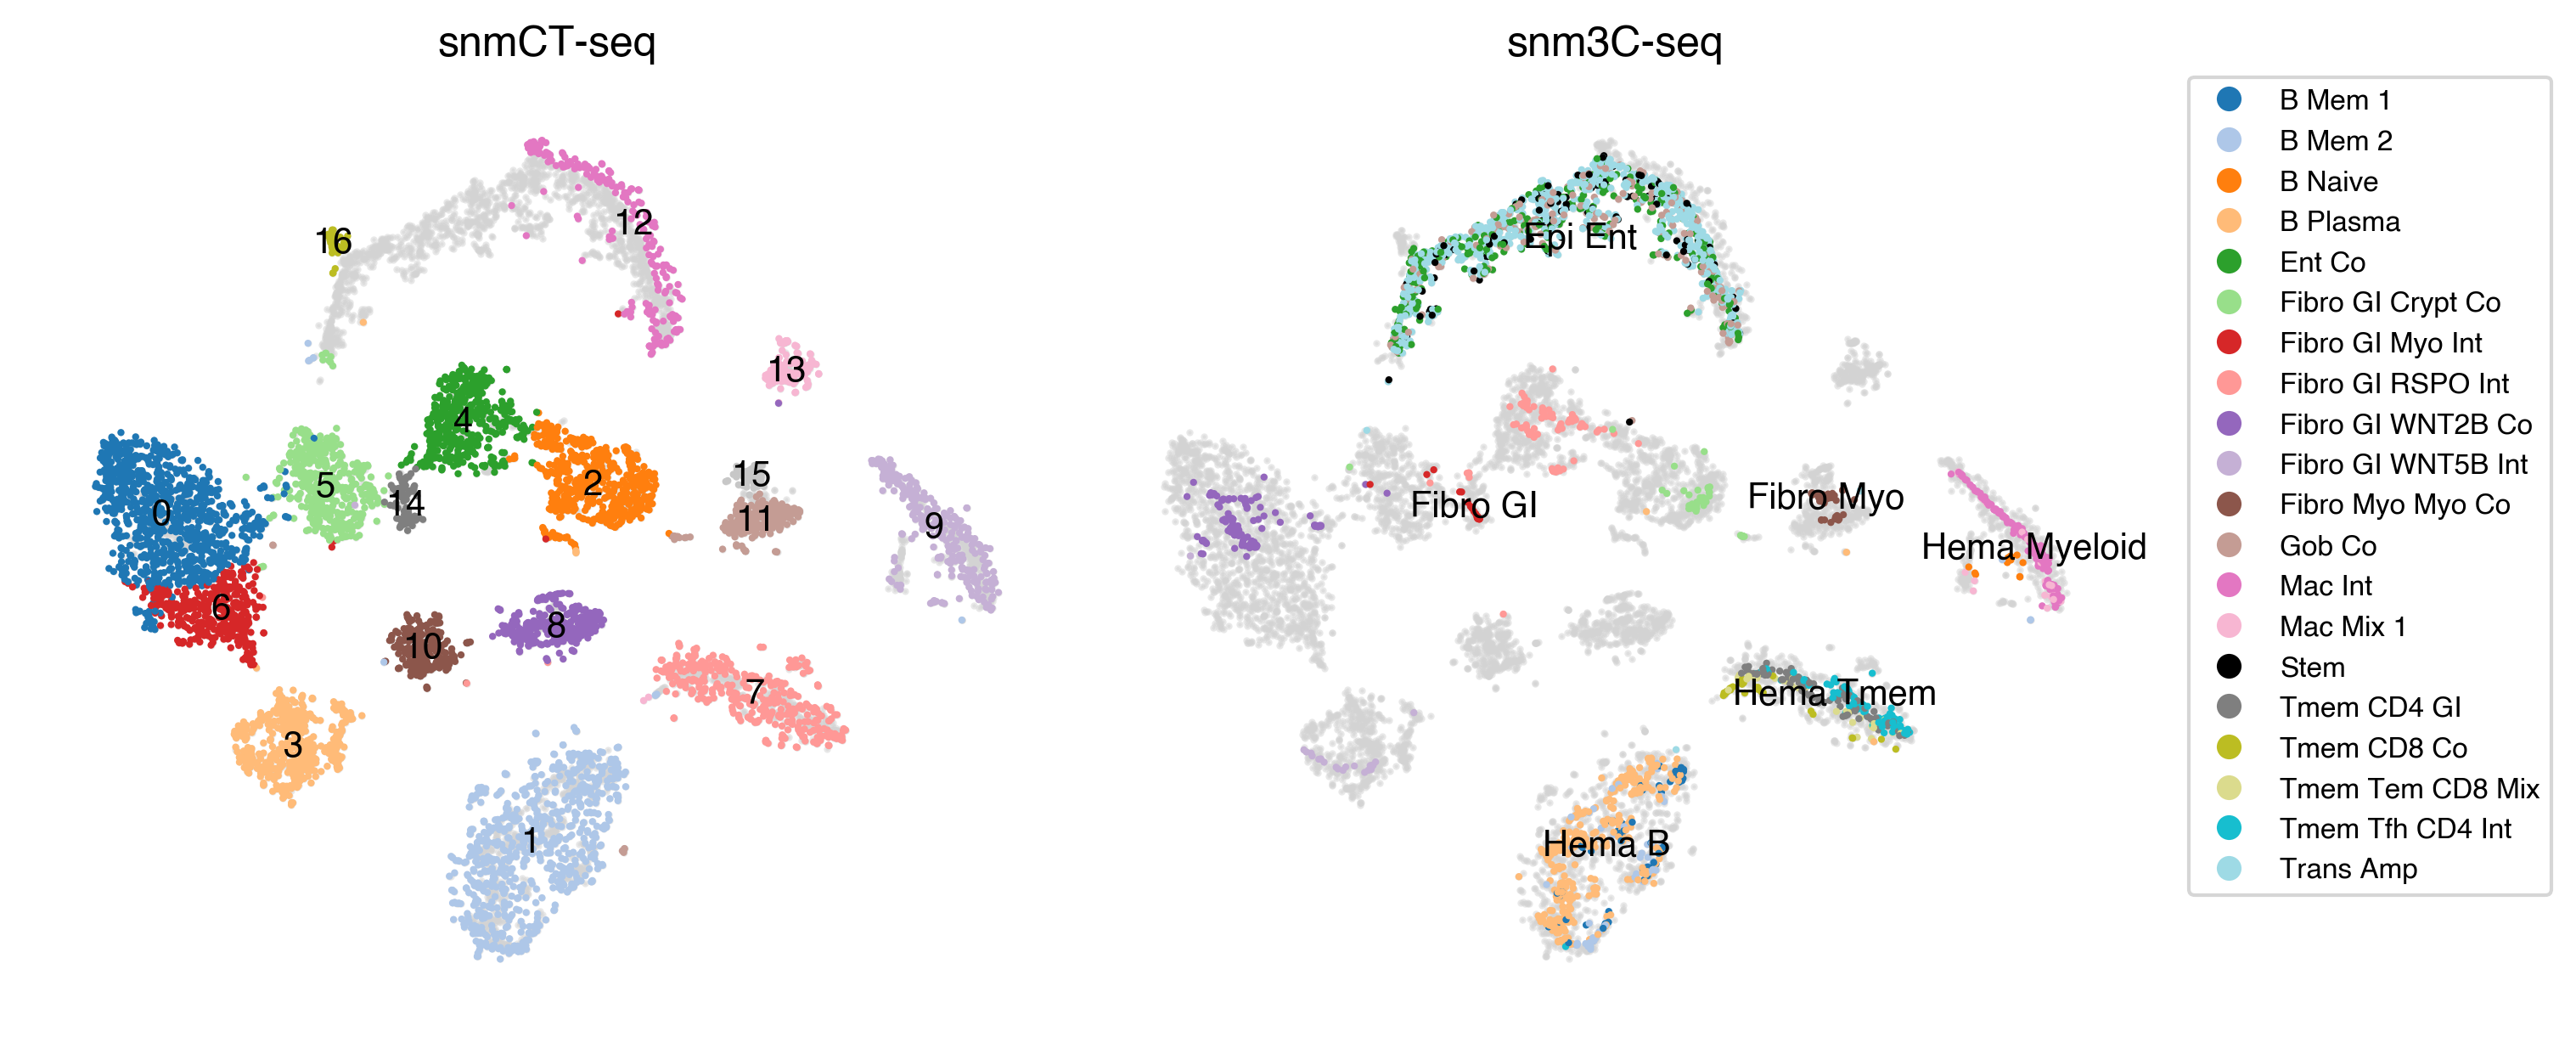

In [38]:
ds = 4
coord_base = 'tsne'

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300, constrained_layout=True)
for i,donor in enumerate(adata1.obs['Donor'].unique()):
    adata_merge = anndata.read_h5ad(f'{outdir}{tissue}_mCT_m3C_{donor}_merged.h5ad')
    # adata_merge.obsm[f'X_{coord_base}'] = adata_merge.obsm[f'5kCG_u{npc}_seuratcc{npc}_tsne'].copy()
    dump_embedding(adata_merge, coord_base)
    tmp = adata_merge.obs.loc[adata_merge.obs['study']=='mCT'].copy()
    ax = axes[0]
    ax.scatter(adata_merge.obsm[f'X_{coord_base}'][:,0], adata_merge.obsm[f'X_{coord_base}'][:,1], s=1, c='lightgrey', alpha=0.5, rasterized=True)
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue=f'5kCG_u16_leiden',
                            # text_anno=f'5kCG_u17hm_leiden',
                            labelsize=8,
                            s=ds,
                            palette=leiden_palette,
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1},
                            # show_legend=True,
                            axis_format='empty',
                            )
    for yy,(x,y) in tmp.groupby('5kCG_u16_leiden')[[f'{coord_base}_0', f'{coord_base}_1']].median().iterrows():
        ax.text(x, y, yy, ha='center', va='center')

    tmp = adata_merge.obs.loc[adata_merge.obs['study']=='m3C'].copy()
    ax = axes[1]
    ax.scatter(adata_merge.obsm[f'X_{coord_base}'][:,0], adata_merge.obsm[f'X_{coord_base}'][:,1], s=1, c='lightgrey', alpha=0.5, rasterized=True)
    tmp = tmp.loc[tmp['L2_annot'].isin(selct)].copy()
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue=f'L2_annot',
                            # text_anno=f'L2_annot',
                            labelsize=8,
                            s=ds,
                            palette=l2_palette,
                            scatter_kws={'rasterized':True},
                            legend_kws={'ncol':1},
                            show_legend=True,
                            axis_format='empty',
                            )
    for yy,(x,y) in tmp.groupby('L1_annot')[[f'{coord_base}_0', f'{coord_base}_1']].median().iterrows():
        ax.text(x, y, yy, ha='center', va='center')

for i,mode in enumerate(['snmCT-seq', 'snm3C-seq']):
    axes[i].set_title(mode)

fig.savefig(f'{outdir}{tissue}_mCT_m3C_integration_seurat.pdf', transparent=True)
